# Reflection and Critic Loop



A reflection loop lets the agent draft, critique, and optionally revise before returning the answer.



## Stack

- Framework: LangGraph iterative workflow

- LLM: local Ollama via `ChatOllama(model="llama3.1:latest")`

- Pattern goal: higher output quality



## When to use it

- Quality matters more than latency

- The task benefits from self-review

## Architecture



```mermaid

graph TD

    T[Topic] --> D[Draft Node]

    D --> C[Critic Node]

    C -->|needs revision| R[Revision Node]

    R --> C

    C -->|approved| O[Final Output]

```

In [ ]:
from visual_diagram_helper import render_svg_flow



nodes = [

    ("topic", "Topic", 60, 170, "#bfdbfe"),

    ("draft", "Draft", 290, 170, "#bbf7d0"),

    ("critique", "Critique", 520, 170, "#fde68a"),

    ("revise", "Revision", 750, 170, "#fecaca"),

    ("final", "Final Output", 980, 170, "#ddd6fe"),

]

edges = [

    ("topic", "draft"),

    ("draft", "critique"),

    ("critique", "revise"),

    ("revise", "final"),

]



render_svg_flow("Reflection Loop Visual Architecture", nodes, edges, width=1220, height=340)

In [ ]:
# Reload shared helpers so any edits to agent_patterns_common.py take effect

# without needing to restart the kernel.

import importlib

import agent_patterns_common



importlib.reload(agent_patterns_common)

print("agent_patterns_common reloaded.")

### Reflection Loop State Graph

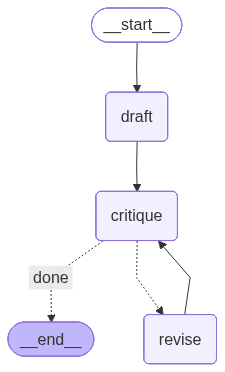

{"level": "INFO", "event_type": "draft_start", "topic": "Why the router pattern improves agent design"}
{"level": "INFO", "event_type": "llm_invoke_start", "attempt": 1, "prompt_preview": "Write EXACTLY 3 bullet points.\nEach bullet must start with '- '.\nEach bullet mus"}
{"level": "INFO", "event_type": "llm_invoke_success", "attempt": 1}
{"level": "INFO", "event_type": "llm_invoke_start", "attempt": 1, "prompt_preview": "Evaluate the draft using this rule only: bullet count and example presence.\nIf v"}
{"level": "INFO", "event_type": "llm_invoke_success", "attempt": 1}
{"level": "INFO", "event_type": "critique_complete", "revision_count": 0}


{'topic': 'Why the router pattern improves agent design',
 'draft': "Here are three bullet points on why the Router pattern improves agent design:\n\n* - The Router pattern allows for a clear separation of concerns between routing logic and business logic, as seen in the example of a banking system where the router handles customer requests while the business logic is encapsulated within the agents.\n* - By using the Router pattern, agents can be designed to handle specific tasks without being overwhelmed by complex routing decisions, such as an order processing agent that only needs to focus on fulfilling orders rather than determining which fulfillment center to use.\n* - The Router pattern enables easier maintenance and scalability of agent design, as demonstrated in a logistics system where new shipping routes are added without requiring changes to the existing agents, thanks to the router's ability to dynamically route requests.",
 'critique': 'APPROVED',
 'revision_count': 0,
 'h

In [ ]:
from langgraph.graph import END, START, StateGraph



from agent_pattern_states import ReflectionState

from agent_patterns_common import (

    append_history,

    build_checkpointer,

    get_local_llm,

    invoke_with_retry,

    log_event,

    render_state_graph,

)





llm = get_local_llm()





def draft_node(state: ReflectionState) -> ReflectionState:

    log_event("info", "draft_start", topic=state["topic"])

    prompt = (

        "Write EXACTLY 3 bullet points.\n"

        "Each bullet must start with '- '.\n"

        "Each bullet must include one concrete example.\n"

        f"Topic: {state['topic']}"

    )

    return {

        "draft": invoke_with_retry(llm, prompt),

        "history": append_history(state.get("history"), "Initial draft created"),

    }





def critique_node(state: ReflectionState) -> ReflectionState:

    prompt = (

        "Evaluate the draft using this rule only: bullet count and example presence.\n"

        "If valid, return EXACTLY 'APPROVED'.\n"

        "If invalid, return EXACTLY 'REVISE: <one short fix>'.\n"

        f"Draft:\n{state['draft']}"

    )

    critique = invoke_with_retry(llm, prompt)

    log_event("info", "critique_complete", revision_count=state["revision_count"])

    return {

        "critique": critique,

        "history": append_history(state["history"], f"Critique: {critique[:80]}"),

    }





def decide_next_step(state: ReflectionState) -> str:

    critique = state["critique"].upper()

    if critique.startswith("APPROVED") or state["revision_count"] >= 1:

        return "done"

    return "revise"





def revise_node(state: ReflectionState) -> ReflectionState:

    prompt = (

        "Rewrite the draft to satisfy the critique.\n"

        "Return EXACTLY 3 bullet points.\n"

        f"Draft:\n{state['draft']}\n\n"

        f"Critique:\n{state['critique']}"

    )

    return {

        "draft": invoke_with_retry(llm, prompt),

        "revision_count": state["revision_count"] + 1,

        "history": append_history(state["history"], "Draft revised"),

    }





builder = StateGraph(ReflectionState)

builder.add_node("draft", draft_node)

builder.add_node("critique", critique_node)

builder.add_node("revise", revise_node)

builder.add_edge(START, "draft")

builder.add_edge("draft", "critique")

builder.add_conditional_edges("critique", decide_next_step, {"revise": "revise", "done": END})

builder.add_edge("revise", "critique")



graph = builder.compile(checkpointer=build_checkpointer())

render_state_graph(graph, "Reflection Loop State Graph")



result = graph.invoke(

    {

        "topic": "Why the router pattern improves agent design",

        "draft": "",

        "critique": "",

        "revision_count": 0,

        "history": [],

    },

    config={"configurable": {"thread_id": "reflection-demo"}},

)



result

## Design insight



Reflection usually improves answers, but it increases latency and token cost. Use it where output quality is worth the extra pass.